In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import linregress
import scienceplots
from numpy.random import SeedSequence
# --- 定义标准高斯PDF以便求Jacobian $H_k$---
def gaussian_pdf(x):
    """Standard Gaussian PDF"""
    if isinstance(x, torch.Tensor):
        return (1.0 / np.sqrt(2 * np.pi)) * torch.exp(-0.5 * x**2)
    else:
        return (1.0 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

In [4]:
# ==========================================
# Enhanced Simulation Function (with H_k and W recording)
# ==========================================
def run_scalar_sr_simulation_full(seed_val, init_sigma, Nx_total=3000, steady_idx=1500):
    """
    Run simulation and record sigma, W, H_k, y_hat
    """
    torch.manual_seed(seed_val)
    np.random.seed(seed_val)
    
    input_data = torch.randn(Nx_total, 1)
    N = 31
    
    # RLS parameters
    W_scalar = torch.tensor([[1.0]])
    P_rls = torch.tensor([[10.0]])
    
    # EKF parameters
    sigma_curr = init_sigma
    P_sigma = 0.5
    Q_sigma = 1e-3
    R_sigma = 1.0
    
    # Recording arrays
    sigma_history = torch.zeros(Nx_total)
    W_history = torch.zeros(Nx_total)
    H_k_history = torch.zeros(Nx_total)
    y_hat_history = torch.zeros(Nx_total)
    
    for k in range(Nx_total):
        x_k = input_data[k, 0]
        
        # Generate noisy observations
        torch.manual_seed(seed_val + 3 * k)
        noise_vec = sigma_curr * torch.randn(N, 1)
        y_vec = torch.sign(x_k + noise_vec)
        phi_k = torch.mean(y_vec)
        
        # RLS update
        y_hat_k = W_scalar * phi_k
        e_k = x_k - y_hat_k
        
        denom = phi_k**2 * P_rls + 0.1
        g_rls = (P_rls * phi_k) / denom
        W_scalar = W_scalar + g_rls * e_k
        P_rls = P_rls - g_rls * phi_k * P_rls
        
        # EKF prediction
        sigma_pred = sigma_curr
        P_sigma_pred = P_sigma + Q_sigma
        
        # Jacobian calculation
        s_safe = max(sigma_pred, 0.01)
        val_y_hat = y_hat_k.item()
        u = val_y_hat / s_safe
        pdf_val = gaussian_pdf(u)
        w_val = W_scalar.item()
        H_k = -2.0 * w_val * (val_y_hat / (s_safe**2)) * pdf_val
        
        # EKF update
        S_innov = H_k**2 * P_sigma_pred + R_sigma
        K_sigma = P_sigma_pred * H_k / S_innov
        step = K_sigma * e_k.item()
        step = max(min(step, 0.2), -0.2)
        
        sigma_new = sigma_pred + step
        sigma_new = max(min(sigma_new, 5.0), 0.03)
        P_sigma = (1 - K_sigma * H_k) * P_sigma_pred
        
        # Record all quantities
        sigma_history[k] = sigma_curr
        W_history[k] = w_val
        H_k_history[k] = H_k
        y_hat_history[k] = val_y_hat
        
        sigma_curr = sigma_new
    
    final_sigma = torch.mean(sigma_history[steady_idx:]).item()
    final_mse = torch.mean((input_data[steady_idx:, 0] - y_hat_history[steady_idx:])**2).item()
    
    return final_sigma, final_mse, sigma_history, W_history, H_k_history, y_hat_history

# ==========================================
# Experimental Setup
# ==========================================
print("\n" + "="*80)
print("4-Panel Analysis: Sigma, W, and H_k Trajectories")
print("Showing COMPLETE convergence process from iteration 0")
print("="*80)

init_values = [0.1, 0.5, 1.5, 4.0]
num_trials = 20
base_seed = 451
Nx_total = 3000
steady_idx = 1500

# Storage for all trajectories
all_results = {init_val: {
    'sigma_trajs': [],
    'W_trajs': [],
    'H_k_trajs': [],
    'final_sigmas': [],
    'final_mses': []
} for init_val in init_values}

# Run experiments
print(f"\nRunning {num_trials} trials for each initial value...")
for init_val in init_values:
    print(f"  Processing Init_Sigma = {init_val}...")
    for trial in range(num_trials):
        seed = base_seed + trial
        final_sig, final_mse, sig_hist, W_hist, H_k_hist, _ = run_scalar_sr_simulation_full(
            seed, init_val, Nx_total, steady_idx
        )
        all_results[init_val]['sigma_trajs'].append(sig_hist.numpy())
        all_results[init_val]['W_trajs'].append(W_hist.numpy())
        all_results[init_val]['H_k_trajs'].append(H_k_hist.numpy())
        all_results[init_val]['final_sigmas'].append(final_sig)
        all_results[init_val]['final_mses'].append(final_mse)

# Calculate statistics
for init_val in init_values:
    all_results[init_val]['sigma_trajs'] = np.array(all_results[init_val]['sigma_trajs'])
    all_results[init_val]['W_trajs'] = np.array(all_results[init_val]['W_trajs'])
    all_results[init_val]['H_k_trajs'] = np.array(all_results[init_val]['H_k_trajs'])
    
    all_results[init_val]['sigma_mean'] = np.mean(all_results[init_val]['sigma_trajs'], axis=0)
    all_results[init_val]['sigma_std'] = np.std(all_results[init_val]['sigma_trajs'], axis=0)
    
    all_results[init_val]['W_mean'] = np.mean(all_results[init_val]['W_trajs'], axis=0)
    all_results[init_val]['W_std'] = np.std(all_results[init_val]['W_trajs'], axis=0)
    
    all_results[init_val]['H_k_mean'] = np.mean(all_results[init_val]['H_k_trajs'], axis=0)
    all_results[init_val]['H_k_std'] = np.std(all_results[init_val]['H_k_trajs'], axis=0)

for init_val in init_values:
    print(f"\nInit Sigma = {init_val}:")
    print(f"  Final Sigma: {np.mean(all_results[init_val]['final_sigmas']):.4f} ± {np.std(all_results[init_val]['final_sigmas']):.4f}")
    print(f"  Final W:     {all_results[init_val]['W_mean'][-1]:.4f} ± {all_results[init_val]['W_std'][-1]:.4f}")
    print(f"  Final MSE:   {np.mean(all_results[init_val]['final_mses']):.4f} ± {np.std(all_results[init_val]['final_mses']):.4f}")
    print(f"  Final H_k:   {all_results[init_val]['H_k_mean'][-1]:.6f} ± {all_results[init_val]['H_k_std'][-1]:.6f}")


4-Panel Analysis: Sigma, W, and H_k Trajectories
Showing COMPLETE convergence process from iteration 0

Running 20 trials for each initial value...
  Processing Init_Sigma = 0.1...
  Processing Init_Sigma = 0.5...
  Processing Init_Sigma = 1.5...
  Processing Init_Sigma = 4.0...

Init Sigma = 0.1:
  Final Sigma: 0.6846 ± 0.1396
  Final W:     1.2396 ± 0.1378
  Final MSE:   0.1371 ± 0.0332
  Final H_k:   -0.031167 ± 0.652248

Init Sigma = 0.5:
  Final Sigma: 0.9735 ± 0.0458
  Final W:     1.5108 ± 0.0437
  Final MSE:   0.1065 ± 0.0078
  Final H_k:   0.002044 ± 0.610459

Init Sigma = 1.5:
  Final Sigma: 1.6370 ± 0.1317
  Final W:     2.0340 ± 0.0913
  Final MSE:   0.1441 ± 0.0149
  Final H_k:   -0.031476 ± 0.447274

Init Sigma = 4.0:
  Final Sigma: 4.0217 ± 0.4089
  Final W:     2.8134 ± 0.0442
  Final MSE:   0.4554 ± 0.0450
  Final H_k:   0.013244 ± 0.117015


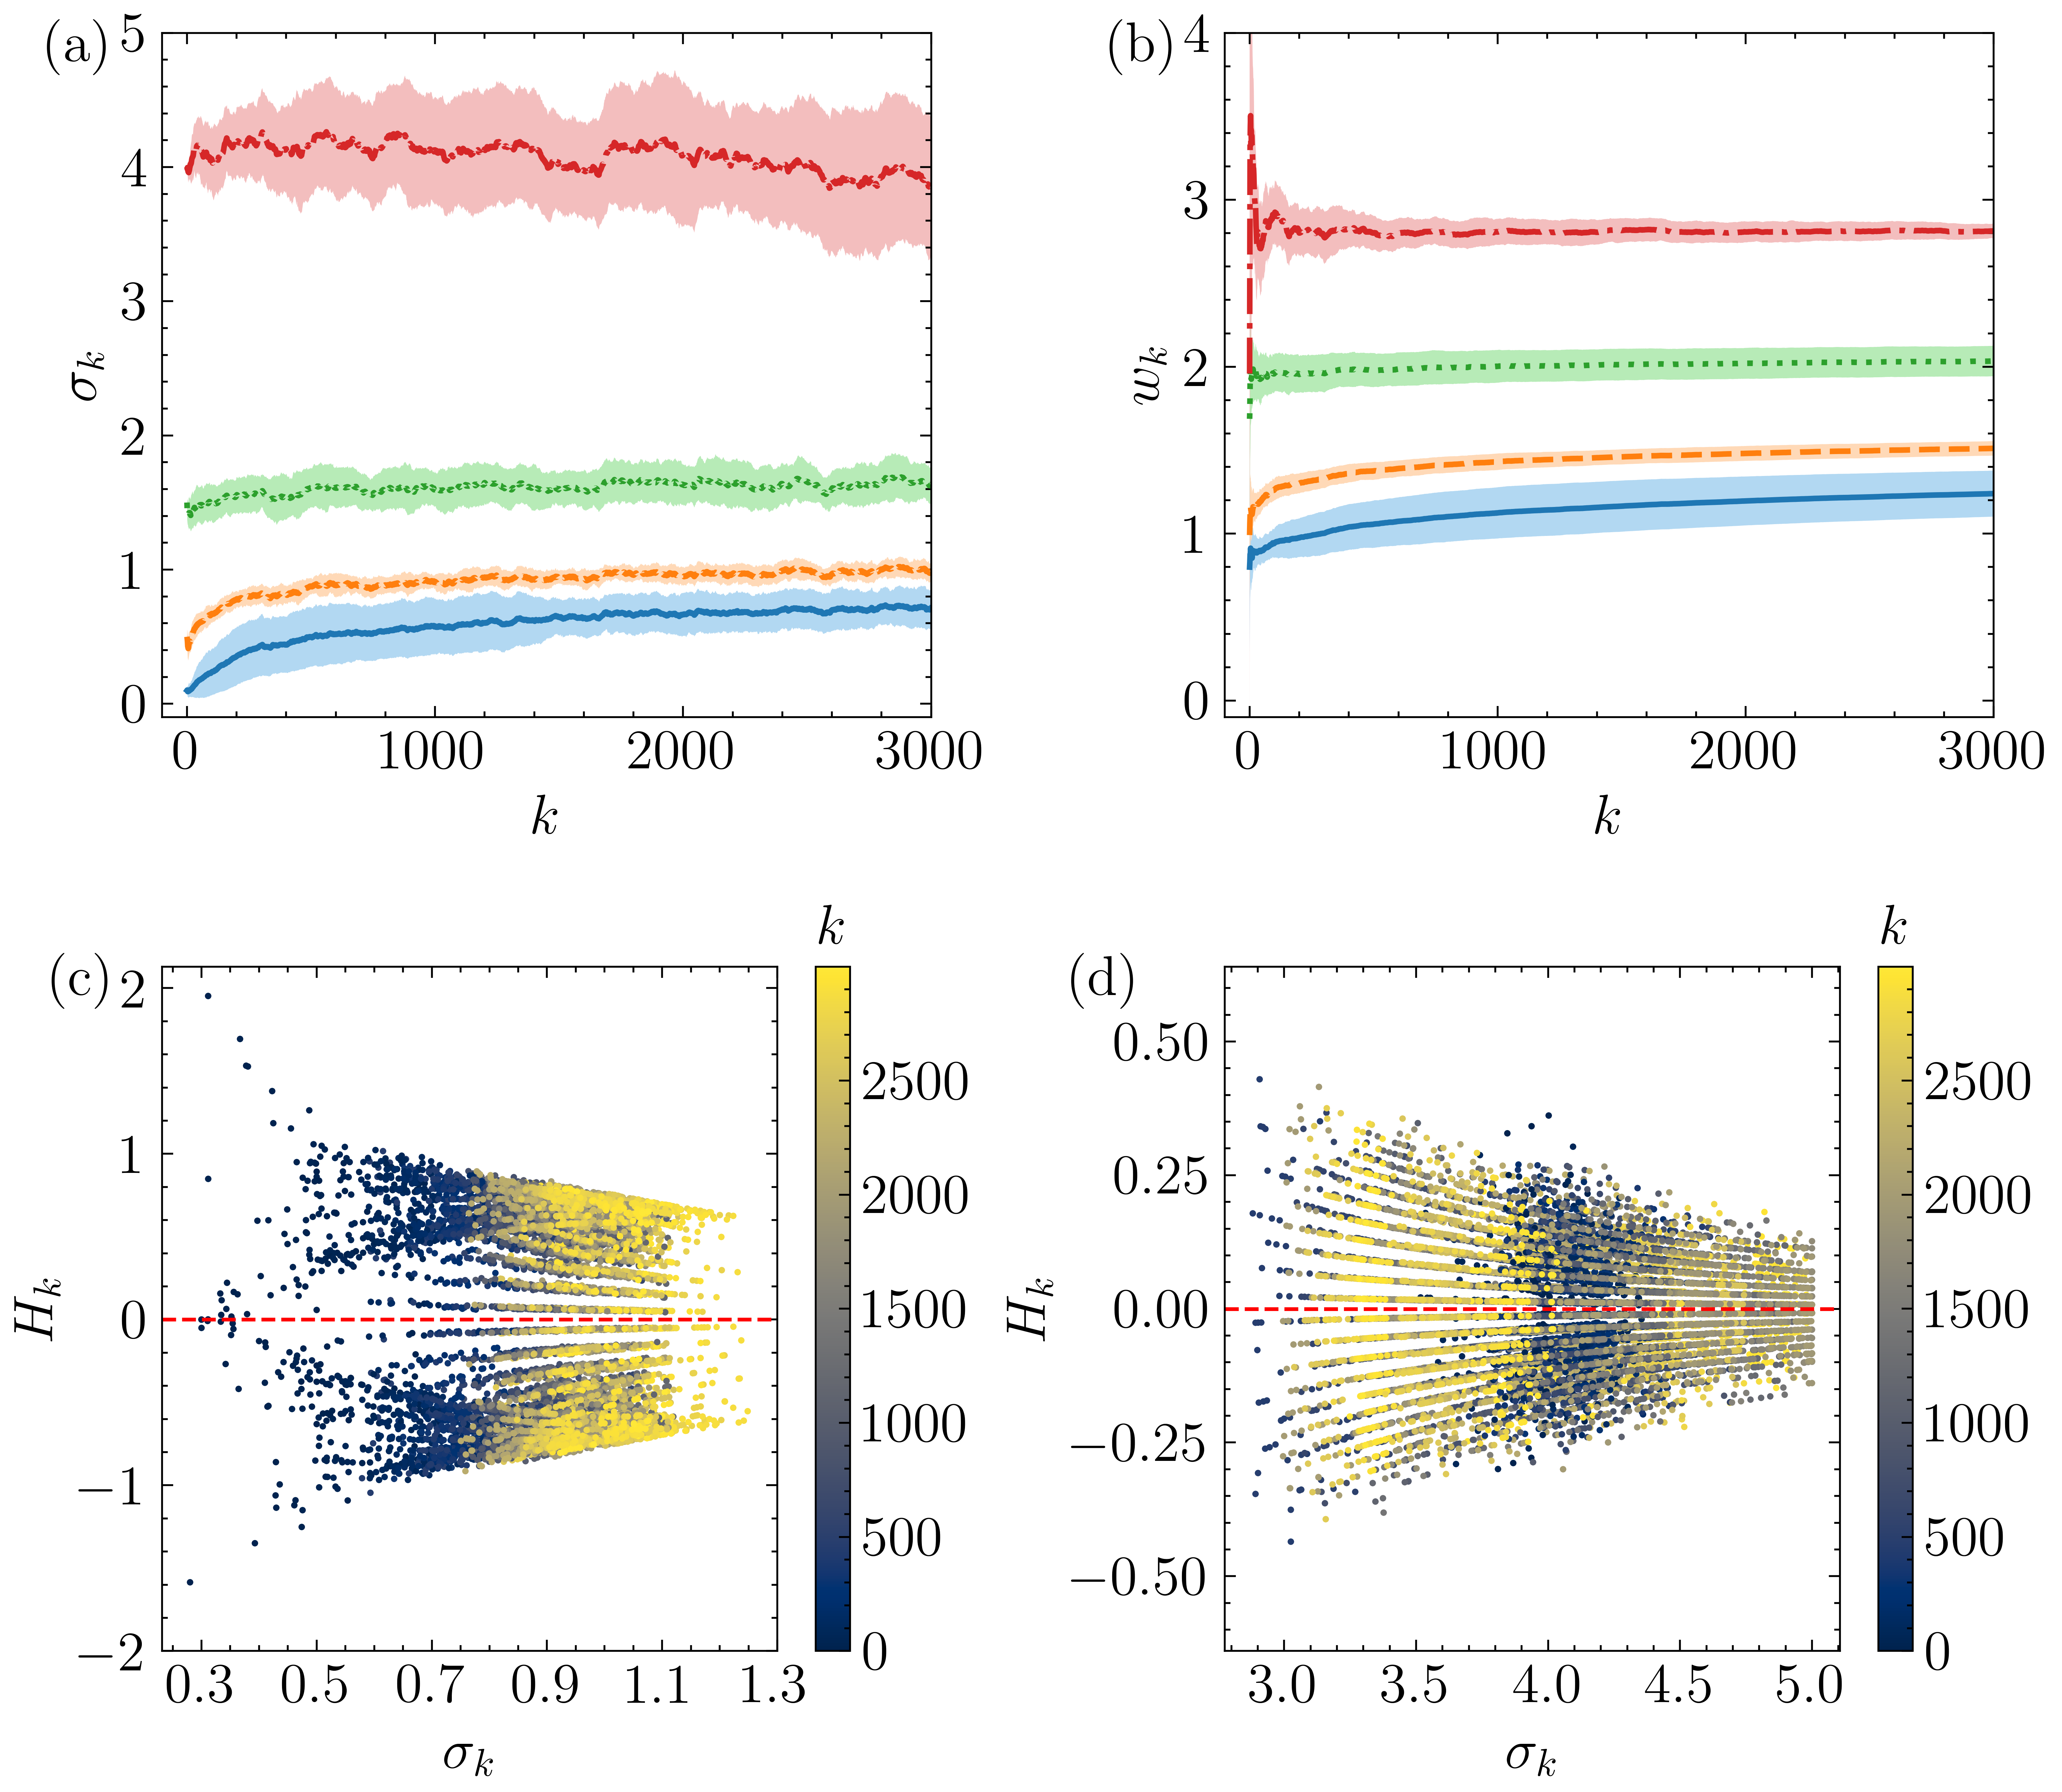

In [15]:
# --- 绘图风格设置 ---
plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',   # 数学公式风格接近 Times
    'font.size': 15,
    'axes.labelsize': 15,
    'legend.fontsize': 15,
})
def lighten_color(color, amount=0.7):
    """
    Lightens the given color by mixing with white
    amount=0 returns white, amount=1 returns original color
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])
# ==========================================
# Create EPS-Compatible Figure
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
axes = axes.flatten()
labels_txt = ['(a)', '(b)', '(c)', '(d)']

# Define colors and their LIGHT versions (instead of alpha)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
light_colors = [lighten_color(c, amount=0.3) for c in colors]  # 30% original, 70% white

iterations = np.arange(Nx_total)

# ==========================================
# Figure 1A: Sigma Convergence - Use LIGHT colors for shading
# ==========================================
ax1a = axes[0]
for i, init_val in enumerate(init_values):
    mean_traj = all_results[init_val]['sigma_mean']
    std_traj = all_results[init_val]['sigma_std']
    
    # Plot shaded region FIRST with light color (NO alpha)
    ax1a.fill_between(iterations, mean_traj - std_traj, mean_traj + std_traj,
                      color=light_colors[i], edgecolor='none')
    
    # Plot mean line on top with dark color
    ax1a.plot(iterations, mean_traj, color=colors[i], linewidth=1.5, 
             label=f'{init_val}')
ax1a.set_ylim(-0.1, 5)
ax1a.set_xlabel(r'$k$')
ax1a.set_ylabel(r'$\sigma_k$')
ax1a.set_yticks([0, 1, 2, 3, 4, 5])
ax1a.set_xlim(-100, Nx_total)
ax1a.text(-0.15, 1.02, labels_txt[0], transform=ax1a.transAxes,
         fontsize=15, va='top')

# ==========================================
# Figure B: Weight W Convergence
# ==========================================
ax2 = axes[1]
mean_traj = all_results[init_val]['W_mean'].copy()
std_traj  = all_results[init_val]['W_std'].copy()

mean_traj[0] = 1.0
std_traj[0]  = 0.0

for i, init_val in enumerate(init_values):
    mean_traj = all_results[init_val]['W_mean']
    std_traj = all_results[init_val]['W_std']
    
    # Shaded region with light color
    ax2.fill_between(iterations, mean_traj - std_traj, mean_traj + std_traj,
                     color=light_colors[i], edgecolor='none')
    
    # Mean line with dark color
    ax2.plot(iterations, mean_traj, color=colors[i], linewidth=1.5)

ax2.set_xlabel(r'$k$')
ax2.set_ylabel(r'$w_k$')
ax2.set_xlim(-100, Nx_total)
ax2.set_ylim(-0.1, 4.0)
ax2.text(-0.15, 1.02, labels_txt[1], transform=ax2.transAxes,
         fontsize=15, va='top')

# ==========================================
# Figure 3: H_k Scatter for Init_Sigma = 0.5
# Use gradient of solid colors (NO alpha in scatter)
# ==========================================
ax3 = axes[2]
init_val_plot = 0.5

# Collect all data from 5 trials
all_sigma = []
all_H_k = []
all_iter = []

for trial_idx in range(min(5, num_trials)):
    H_k_sample = all_results[init_val_plot]['H_k_trajs'][trial_idx, :]
    sigma_sample = all_results[init_val_plot]['sigma_trajs'][trial_idx, :]
    all_sigma.extend(sigma_sample)
    all_H_k.extend(H_k_sample)
    all_iter.extend(iterations)

# Create scatter with solid colors (size smaller to reduce overlap)
scatter = ax3.scatter(all_sigma, all_H_k, c=all_iter, cmap='cividis',
                     s=3, edgecolors='none', rasterized=True)  # rasterized for EPS

cbar = plt.colorbar(scatter, ax=ax3)
cbar.ax.set_title(r'$k$', fontsize=15, pad=6)

ax3.axhline(y=0, color='red', linestyle='--', linewidth=1.0)
ax3.set_xticks([0.3, 0.5, 0.7, 0.9, 1.1, 1.3])
ax3.set_xlabel(r'$\sigma_k$')
ax3.set_ylabel(r'$H_k$')
ax3.set_yticks([-2.0, -1.0, 0.0, 1.0, 2.0])
ax4.set_ylim(-2.1, 2.1)
ax3.text(-0.18, 1.02, labels_txt[2], transform=ax3.transAxes,
         fontsize=15, va='top')

# ==========================================
# Figure 4: H_k Scatter for Init_Sigma = 4.0
# ==========================================
ax4 = axes[3]
init_val_plot = 4.0

all_sigma = []
all_H_k = []
all_iter = []

for trial_idx in range(min(5, num_trials)):
    H_k_sample = all_results[init_val_plot]['H_k_trajs'][trial_idx, :]
    sigma_sample = all_results[init_val_plot]['sigma_trajs'][trial_idx, :]
    all_sigma.extend(sigma_sample)
    all_H_k.extend(H_k_sample)
    all_iter.extend(iterations)

scatter = ax4.scatter(all_sigma, all_H_k, c=all_iter, cmap='cividis',
                     s=3, edgecolors='none', rasterized=True)

cbar = plt.colorbar(scatter, ax=ax4)
cbar.ax.set_title(r'$k$', fontsize=15, pad=6)

ax4.axhline(y=0, color='red', linestyle='--', linewidth=1.0)
ax4.set_xticks([3.0, 3.5, 4.0, 4.5, 5.0])
ax4.set_xlabel(r'$\sigma_k$')
ax4.set_ylabel(r'$H_k$')
ax4.set_ylim(-0.64, 0.64)
ax4.text(-0.25, 1.02, labels_txt[3], transform=ax4.transAxes,
         fontsize=15, va='top')
fig.savefig(
    'D:/IEEE 2025 Adaptive weighted SSR/Fig8.eps',
    format='eps',
    dpi=800,
    bbox_inches='tight'
)
plt.tight_layout()